# Comparision between Nelder-Mead, Optimal-Filter and Constrained Optimal Filter

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
from scipy.optimize import minimize
import seaborn as sns
from datetime import datetime

In [3]:
# # TRANSFORMING THE ORIGINAL DATA TO THE DATA USED IN THE ALGORITHMS
# import pandas as pd

# def getOriginalData(path):

#     data = pd.read_csv(path)
#     samples = data['sample'].values
#     amplitudes = data['amplitude'].values

#     pulses = []
#     s4_amplitudes = []
#     for i in range( len(samples)-6 ):
#         pulses.append( samples[ i:i+7 ] )
#         s4_amplitudes.append(amplitudes[i+3])

#     return pulses, s4_amplitudes

# datas = [getOriginalData(r'.\database\original-database\occupancy_0.2.CSV'),
#          getOriginalData(r'.\database\original-database\occupancy_0.5.CSV'),
#          getOriginalData(r'.\database\original-database\occupancy_0.7.CSV'),
#          getOriginalData(r'.\database\original-database\occupancy_0.9.CSV')
#          ]

# samples = pd.DataFrame(datas[0][0], columns = [f"sample({i+1})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[0][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_2.csv', index = False)

# samples = pd.DataFrame(datas[1][0], columns = [f"sample({i})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[1][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_5.csv', index = False)

# samples = pd.DataFrame(datas[2][0], columns = [f"sample({i})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[2][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_7.csv', index = False)

# samples = pd.DataFrame(datas[3][0], columns = [f"sample({i})" for i in range(7)])
# amplitudes = pd.DataFrame(datas[3][1], columns = ['AmplitudeSample(4)'])
# data = pd.concat((samples, amplitudes), axis = 1)
# data.to_csv(r'.\database\data_occ0_9.csv', index = False)

In [4]:
# AUXILIARY FUNCTIONS
## Train Test Split
def trainTestSplit( data, train_prop = 0.5 ):

    threshold = int( len( data ) * train_prop )
    train = data[ : threshold ]
    test = data[ threshold : ]

    return train, test

## Calculate Residuals
def getResidual( real_values, estimated_values, show = False ):

    residuals = np.array(real_values) - np.array(estimated_values)

    if show == True:
        fig, ax = plt.subplots(figsize = (10, 10))
        ax.hist(residuals, bins = 50)
        ax.set_xlabel('Residual Value')
        ax.set_ylabel('Frequency')
        plt.show()
    
    return residuals

# OPTMIZATION METHODS
## OF2 (Optimal Filter)
def optimalFilter2( train, test ):

    def of2Weights( train ):

        pulse = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])
        d_pulse = np.array([0.00004019, 0.00333578, 0.03108120, 0.00000000, -0.02434490, -0.00800683, -0.00243344])

        train = np.array(train).T
        covarianceMatrix = np.cov(train)

        b = np.zeros((10,10))
        b[ 0:7, 0:7 ] = covarianceMatrix
        b[ 0:7, 7 ] = -pulse
        b[ 0:7, 8 ] = -d_pulse
        b[ 0:7, 9 ] = -1
        b[ 7, 0:7 ] = pulse
        b[ 8, 0:7 ] = d_pulse
        b[ 9, 0:7 ] = 1

        c = np.zeros((10, 1))
        c[7] = 1
        
        aux = np.linalg.solve( b, c )
        weights = aux[0:7].flatten()

        return weights

    weights = of2Weights( train )

    sample4 = []
    for i in range(len(test)):
        auxSample = test[i] * weights
        auxSample4 = sum(auxSample)
        sample4.append(auxSample4)

    return sample4

## Nelder-Mead
def nelderMead( train, test ): # train is not used

    def objectiveFunction(A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5
    
    sample4 = []
    for samples in test:
        sample4.append((minimize(objectiveFunction, samples, method='Nelder-Mead', options={'xatol': 1e-4}).x)[3])

    return sample4

## COF (Constrained Optimal Filter)
def constrainedOptimalFilter( train, test ):

    pulse = np.array([0.00002304, 0.01722640, 0.45244500, 1.0, 0.56330700, 0.14933500, 0.04235980])
    S = np.array([
        [pulse[3],   pulse[4],   pulse[5],   pulse[6],   0.0,       0.0,        0.0     ],
        [pulse[2],   pulse[3],   pulse[4],   pulse[5],   pulse[6],  0.0,        0.0     ],
        [pulse[1],   pulse[2],   pulse[3],   pulse[4],   pulse[5],  pulse[6],   0.0     ],
        [pulse[0],   pulse[1],   pulse[2],   pulse[3],   pulse[4],  pulse[5],   pulse[6]],
        [0.0,        pulse[0],   pulse[1],   pulse[2],   pulse[3],  pulse[4],   pulse[5]],
        [0.0,        0.0,        pulse[0],   pulse[1],   pulse[2],  pulse[3],   pulse[4]],
        [0.0,        0.0,        0.0,        pulse[0],   pulse[1],  pulse[2],   pulse[3]]
    ])

    inv_S = np.linalg.inv(S)
    
    sample4 = []
    for samples in test:
        sample4.append( (inv_S @ samples)[3] )

    return sample4   



In [5]:
# LOADING THE DATA
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv')]

columns = data[0].columns # Getting the columns names

In [6]:
# DEFINING THE PARAMETERS
trainSize = 0.8 # Size of the training set
mode = {  # 'save' (calculates and saves the results) or 'load' (loads the results)
    'nm': 'load', 
    'of2': 'load', 
    'cof': 'load'
    }
show = False # Shows each result separately (recommended "false" if the intention is to compare all models)

In [7]:
def runAlgorithms(data, trainProp, mode, show=False):

    ## Optimal Filter 2
    if(mode['of2'] == 'save'):
        residuals = []
        times = []
        for i in range(len(data)):
            trainData, testData = trainTestSplit(np.array(data[i][columns[0:7]]), train_prop=trainProp)
            _, testAmplitude = trainTestSplit(np.array(data[i][columns[7]]), train_prop=trainProp)

            start = datetime.now()
            sample4 = optimalFilter2(trainData, testData)
            times.append(datetime.now() - start)
            
            residuals.append(getResidual(testAmplitude, sample4, show))

        OF2_residuals = pd.DataFrame(np.array(residuals).T, columns = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"])
        OF2_residuals.to_csv(r'.\results\of2_residuals.csv', index = False)
        OF2_times = pd.DataFrame([times], columns = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"])
        OF2_times.to_csv(r'.\results\of2_times.csv', index = False)
    else:
        OF2_residuals = pd.read_csv(r'.\results\of2_residuals.csv')
        OF2_times = pd.read_csv(r'.\results\of2_times.csv')

    ## Nelder-Mead
    if(mode['nm'] == 'save'):
        residuals = []
        times = []
        for i in range(len(data)):
            trainData, testData = trainTestSplit(np.array(data[i][columns[0:7]]), train_prop=trainProp)
            _, testAmplitude = trainTestSplit(np.array(data[i][columns[7]]), train_prop=trainProp)

            start = datetime.now()
            sample4 = nelderMead(trainData, testData)
            times.append(datetime.now() - start)
            
            residuals.append(getResidual(testAmplitude, sample4, show))

        NM_residuals = pd.DataFrame(np.array(residuals).T, columns = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"])
        NM_residuals.to_csv(r'.\results\nm_residuals.csv', index = False)
        NM_times = pd.DataFrame([times], columns = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"])
        NM_times.to_csv(r'.\results\nm_times.csv', index = False)
    else:
        NM_residuals = pd.read_csv(r'.\results\nm_residuals.csv')
        NM_times = pd.read_csv(r'.\results\nm_times.csv')

    ## Constrained Optimal Filter
    if(mode['cof'] == 'save'):
        residuals = []
        times = []
        for i in range(len(data)):
            trainData, testData = trainTestSplit(np.array(data[i][columns[0:7]]), train_prop=trainProp)
            _, testAmplitude = trainTestSplit(np.array(data[i][columns[7]]), train_prop=trainProp)

            start = datetime.now()
            sample4 = constrainedOptimalFilter(trainData, testData)
            times.append(datetime.now() - start)
            
            residuals.append(getResidual(testAmplitude, sample4, show))

        COF_residuals = pd.DataFrame(np.array(residuals).T, columns = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"])
        COF_residuals.to_csv(r'.\results\cof_residuals.csv', index = False)
        COF_times = pd.DataFrame([times], columns = ["occ0_2", "occ0_5", "occ0_7", "occ0_9"])
        COF_times.to_csv(r'.\results\cof_times.csv', index = False)
    else:
        COF_residuals = pd.read_csv(r'.\results\cof_residuals.csv')
        COF_times = pd.read_csv(r'.\results\cof_times.csv')

    return OF2_residuals, OF2_times, NM_residuals, NM_times, COF_residuals, COF_times

    

In [8]:
OF2_residuals, OF2_times, NM_residuals, NM_times, COF_residuals, COF_times = runAlgorithms(data, trainSize, mode, show)

In [9]:
# Calculating the mean and standard deviation of the residuals
cof_means = []
cof_stds = []
nm_means = []
nm_stds = []
of2_means = []
of2_stds = []
occ = [20, 50, 70, 90]

for collum in COF_residuals:
    cof_means.append(COF_residuals[collum].mean())
    nm_means.append(NM_residuals[collum].mean())
    of2_means.append(OF2_residuals[collum].mean())

    cof_stds.append(COF_residuals[collum].std())
    nm_stds.append(NM_residuals[collum].std())
    of2_stds.append(OF2_residuals[collum].std())

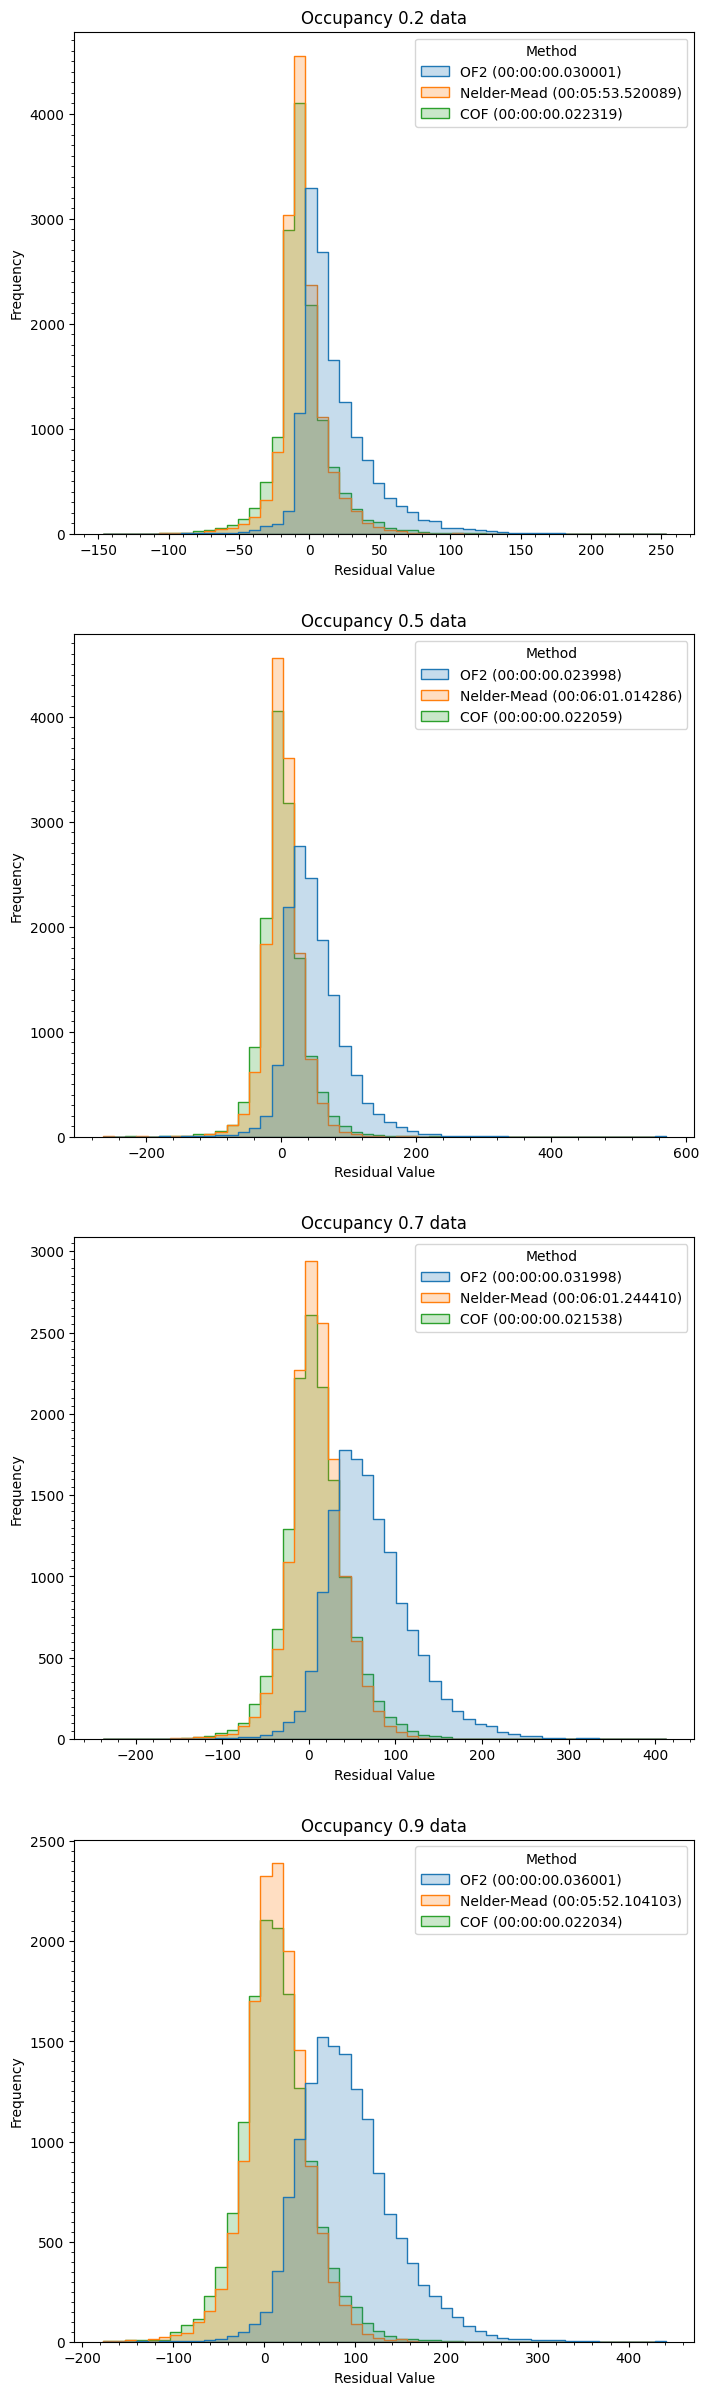

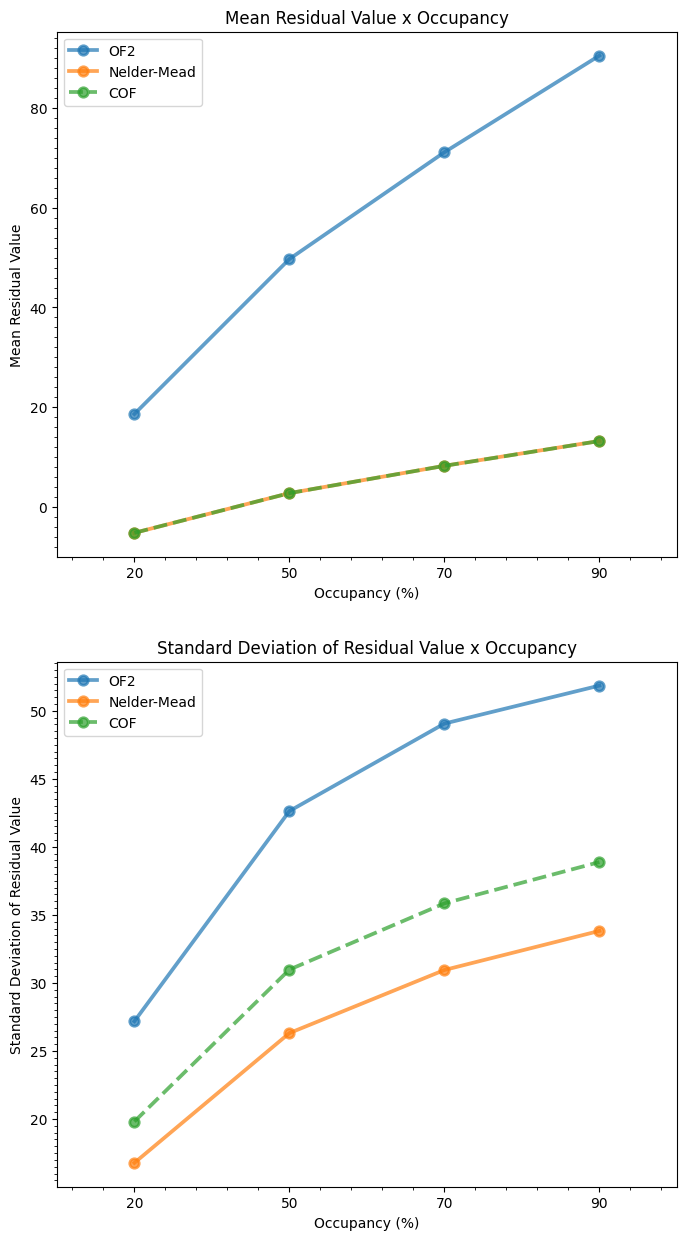

In [10]:
palette = [
    "#1f77b4",  # OF2
    "#ff7f0e",  # Nelder-Mead
    "#2ca02c"   # COF
]

fig, ax = plt.subplots(nrows = 4, ncols = 1, figsize = (8, 30))
for a in ax:
    a.yaxis.set_minor_locator(AutoMinorLocator(10))
    a.xaxis.set_minor_locator(AutoMinorLocator(5))

results0_2 = pd.concat([pd.DataFrame({"Residual Value": np.array(OF2_residuals["occ0_2"]), "Method": f"OF2 ({OF2_times["occ0_2"][0][7:]})"}),
                       pd.DataFrame({"Residual Value": np.array(NM_residuals["occ0_2"]), "Method": f"Nelder-Mead ({NM_times["occ0_2"][0][7:]})"}),
                       pd.DataFrame({"Residual Value": np.array(COF_residuals["occ0_2"]), "Method": f"COF ({COF_times["occ0_2"][0][7:]})"})])
sns.histplot(data = results0_2, hue = "Method", x = "Residual Value", bins = 50, ax = ax[0], element="step", palette=palette)
ax[0].set_ylabel("Frequency")
ax[0].set_title("Occupancy 0.2 data")

results0_5 = pd.concat([pd.DataFrame({"Residual Value": np.array(OF2_residuals["occ0_5"]), "Method": f"OF2 ({OF2_times["occ0_5"][0][7:]})"}),
                       pd.DataFrame({"Residual Value": np.array(NM_residuals["occ0_5"]), "Method": f"Nelder-Mead ({NM_times["occ0_5"][0][7:]})"}),
                       pd.DataFrame({"Residual Value": np.array(COF_residuals["occ0_5"]), "Method": f"COF ({COF_times["occ0_5"][0][7:]})"})])
sns.histplot(data = results0_5, hue = "Method", x = "Residual Value", bins = 50, ax = ax[1], element="step", palette=palette)
ax[1].set_ylabel("Frequency")
ax[1].set_title("Occupancy 0.5 data")

results0_7 = pd.concat([pd.DataFrame({"Residual Value": np.array(OF2_residuals["occ0_7"]), "Method": f"OF2 ({OF2_times["occ0_7"][0][7:]})"}),
                       pd.DataFrame({"Residual Value": np.array(NM_residuals["occ0_7"]), "Method": f"Nelder-Mead ({NM_times["occ0_7"][0][7:]})"}),
                       pd.DataFrame({"Residual Value": np.array(COF_residuals["occ0_7"]), "Method": f"COF ({COF_times["occ0_7"][0][7:]})"})])
sns.histplot(data = results0_7, hue = "Method", x = "Residual Value", bins = 50, ax = ax[2], element="step", palette=palette)
ax[2].set_ylabel("Frequency")
ax[2].set_title("Occupancy 0.7 data")

results0_9 = pd.concat([pd.DataFrame({"Residual Value": np.array(OF2_residuals["occ0_9"]), "Method": f"OF2 ({OF2_times["occ0_9"][0][7:]})"}),
                       pd.DataFrame({"Residual Value": np.array(NM_residuals["occ0_9"]), "Method": f"Nelder-Mead ({NM_times["occ0_9"][0][7:]})"}),
                       pd.DataFrame({"Residual Value": np.array(COF_residuals["occ0_9"]), "Method": f"COF ({COF_times["occ0_9"][0][7:]})"})])
sns.histplot(data = results0_9, hue = "Method", x = "Residual Value", bins = 50, ax = ax[3], element="step", palette=palette)
ax[3].set_ylabel("Frequency")
ax[3].set_title("Occupancy 0.9 data")

plt.show()

fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (8, 15))
for a in ax:
    a.yaxis.set_minor_locator(AutoMinorLocator(10))
    a.xaxis.set_minor_locator(AutoMinorLocator(5))

sns.pointplot(x=occ, y=of2_means, ax=ax[0], label='OF2', color=palette[0], alpha=0.7)
sns.pointplot(x=occ, y=nm_means, ax=ax[0], label='Nelder-Mead', color=palette[1], linestyles='-', alpha=0.7)
sns.pointplot(x=occ, y=cof_means, ax=ax[0], label='COF', color=palette[2], linestyles='--', alpha=0.7)
ax[0].set_xlabel("Occupancy (%)")
ax[0].set_ylabel("Mean Residual Value")
ax[0].set_title("Mean Residual Value x Occupancy")

sns.pointplot(x=occ, y=of2_stds, ax=ax[1], label='OF2', color=palette[0], alpha=0.7)
sns.pointplot(x=occ, y=nm_stds, ax=ax[1], label='Nelder-Mead', color=palette[1], linestyles='-', alpha=0.7)
sns.pointplot(x=occ, y=cof_stds, ax=ax[1], label='COF', color=palette[2], linestyles='--', alpha=0.7)
ax[1].set_xlabel("Occupancy (%)")
ax[1].set_ylabel("Standard Deviation of Residual Value")
ax[1].set_title("Standard Deviation of Residual Value x Occupancy")

plt.show()

In [11]:
# # OLD 
# OF2_residuals = []
# NM_residuals = []
# NM_time = []

# # Dataset with occupancy 0.2
# trainData, testData = trainTestSplit(np.array(data[0][columns[0:7]]), trainSize)
# _, testAmplitude = trainTestSplit(np.array(data[0][columns[7]]), trainSize)

# sample4 = optimalFilter2(trainData, testData)
# OF2_residuals.append(getResidual(testAmplitude, sample4, show))
# start = datetime.now()
# sample4 = nelderMead(trainData, testData)
# NM_time.append(datetime.now() - start)
# NM_residuals.append(getResidual(testAmplitude, sample4, show))

# # Dataset with occupancy 0.5
# trainData, testData = trainTestSplit(np.array(data[1][columns[0:7]]), trainSize)
# _, testAmplitude = trainTestSplit(np.array(data[1][columns[7]]), trainSize)

# sample4 = optimalFilter2(trainData, testData)
# OF2_residuals.append(getResidual(testAmplitude, sample4, show))
# start = datetime.now()
# sample4 = nelderMead(trainData, testData)
# NM_time.append(datetime.now() - start)
# NM_residuals.append(getResidual(testAmplitude, sample4, show))

# # Dataset with occupancy 0.7
# trainData, testData = trainTestSplit(np.array(data[2][columns[0:7]]), trainSize)
# _, testAmplitude = trainTestSplit(np.array(data[2][columns[7]]), trainSize)

# sample4 = optimalFilter2(trainData, testData)
# OF2_residuals.append(getResidual(testAmplitude, sample4, show))
# start = datetime.now()
# sample4 = nelderMead(trainData, testData)
# NM_time.append(datetime.now() - start)
# NM_residuals.append(getResidual(testAmplitude, sample4, show))

# # Dataset with occupancy 0.9
# trainData, testData = trainTestSplit(np.array(data[3][columns[0:7]]), trainSize)
# _, testAmplitude = trainTestSplit(np.array(data[3][columns[7]]), trainSize)

# sample4 = optimalFilter2(trainData, testData)
# OF2_residuals.append(getResidual(testAmplitude, sample4, show))
# start = datetime.now()
# sample4 = nelderMead(trainData, testData)
# NM_time.append(datetime.now() - start)
# NM_residuals.append(getResidual(testAmplitude, sample4, show))